<a href="https://colab.research.google.com/github/baranshad/cs7643-project/blob/main/7643_finalprojectg_usecopyimage_otherwisetotallymessed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
import shutil
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import h5py
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import models
from PIL import ImageFile
pd.set_option('display.max_columns', None)
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import copy

In [ ]:
!git config --global user.email "baranshadyuan@gmail.com"
!git config --global user.name "Yuan Gu"
!git clone https://github.com/yourusername/yourrepo.git
%cd yourrepo
!cp /content/your_notebook.ipynb .
!git add your_notebook.ipynb
!git commit -m "Add notebook"
!git push

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#os.chdir('/content/drive/My Drive/7643_finalproject02192025')
#!unzip -q "archive.zip" -d "/content/drive/My Drive/7643_finalproject02192025/extract"

# New Section

In [ ]:
os.chdir('/content/drive/My Drive/7643_finalproject02192025/extract') ## small data is in extract

In [ ]:
metadata = pd.read_csv('HAM10000_metadata.csv')
print(metadata.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [ ]:
print(metadata.dx.unique())
print(metadata.dx_type.unique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
['histo' 'consensus' 'confocal' 'follow_up']


In [ ]:
binary_map = {
  "nv": "Benign",
     "bkl":"Benign",
     "df": "Benign",
     "vasc": "Benign",
     "mel": "Not Benign",
     "bcc":  "Not Benign",
     "akiec":  "Not Benign"
}

metadata["target"] = metadata["dx"].map(binary_map)

In [ ]:
print(metadata.target.unique())

['Benign' 'Not Benign']


In [ ]:
lesion_counts = metadata['lesion_id'].value_counts()
metadata['duplicates'] = metadata['lesion_id'].map(lambda x: 'duplicated' if lesion_counts[x] > 1 else 'unduplicated')

In [ ]:
print(metadata.head())

     lesion_id      image_id   dx dx_type   age   sex localization  target  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp  Benign   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp  Benign   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp  Benign   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp  Benign   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear  Benign   

   duplicates  
0  duplicated  
1  duplicated  
2  duplicated  
3  duplicated  
4  duplicated  


target
Benign        8061
Not Benign    1954
Name: count, dtype: int64


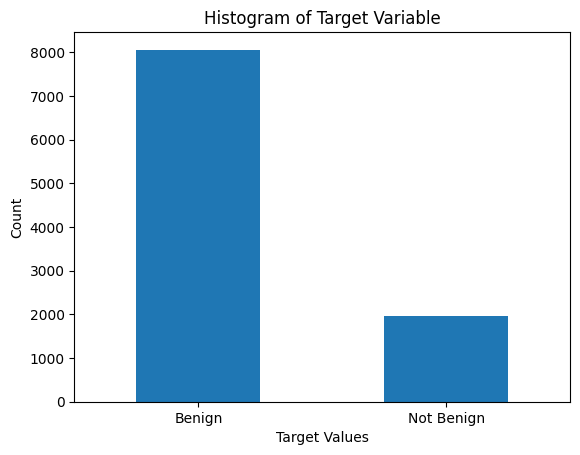

In [ ]:
print(metadata.target.value_counts())
#print(6301/1169)
metadata.target.value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel('Target Values')
plt.ylabel('Count')
plt.title('Histogram of Target Variable')
plt.xticks(rotation=0)  # <-- This keeps x-axis labels horizontal
plt.show()

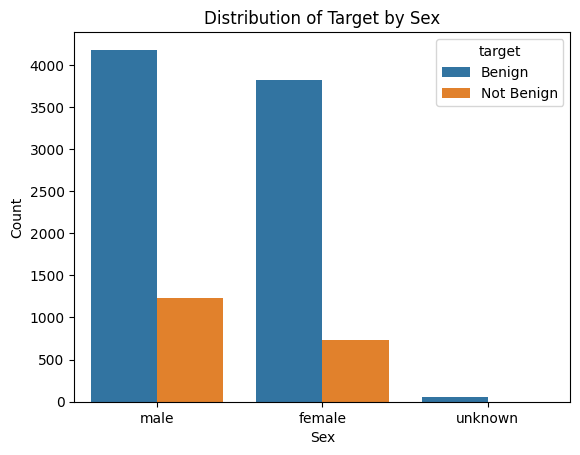

In [ ]:
sns.countplot(data=metadata, x='sex', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by Sex')
plt.show()

In [ ]:
## randomly select one image_id for the duplicated ids, if not duplicated, just select the unique one
metadata_unique = metadata.groupby('lesion_id').sample(n=1, random_state=42).reset_index(drop=True)

target
Benign        6301
Not Benign    1169
Name: count, dtype: int64
5.390076988879384


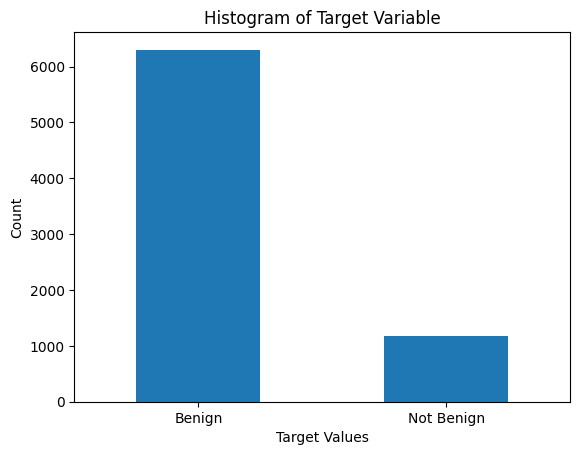

In [ ]:
print(metadata_unique.target.value_counts())
print(6301/1169)
metadata.target.value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel('Target Values')
plt.ylabel('Count')
plt.title('Histogram of Target Variable')
plt.xticks(rotation=0)  # <-- This keeps x-axis labels horizontal
plt.show()


In [ ]:
print(metadata_unique.shape)

(7470, 9)


In [ ]:
image_dirs = ['HAM10000_images_part_1', 'HAM10000_images_part_2',
              'ham10000_images_part_1', 'ham10000_images_part_2']
merged_image_dir = 'all_images'
os.makedirs(merged_image_dir, exist_ok=True)
for img_dir in image_dirs:
    for fname in os.listdir(img_dir):
        src = os.path.join(img_dir, fname)
        dst = os.path.join(merged_image_dir, fname)
        if not os.path.exists(dst):
            shutil.copyfile(src, dst)

In [ ]:
metadata = metadata_unique

In [ ]:
metadata['image_path'] = metadata['image_id'] + '.jpg'
metadata['full_path'] = metadata['image_path'].apply(lambda x: os.path.join(merged_image_dir, x))
train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['target'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['target'], random_state=42)

In [ ]:
print(os.getcwd())
print(train_val_df.head())
print(train_val_df['target'].unique())

/content/drive/MyDrive/7643_finalproject02192025/extract
        lesion_id      image_id   dx    dx_type   age     sex  \
2771  HAM_0002792  ISIC_0033169  bkl  consensus  80.0  female   
2938  HAM_0002962  ISIC_0028331  bkl  consensus  80.0    male   
6173  HAM_0006285  ISIC_0030596   nv  follow_up  50.0    male   
5584  HAM_0005672  ISIC_0028388  bkl      histo  50.0  female   
6666  HAM_0006793  ISIC_0030796   nv      histo  60.0  female   

         localization  target    duplicates        image_path  \
2771             back  Benign  unduplicated  ISIC_0033169.jpg   
2938             back  Benign  unduplicated  ISIC_0028331.jpg   
6173  upper extremity  Benign  unduplicated  ISIC_0030596.jpg   
5584             face  Benign    duplicated  ISIC_0028388.jpg   
6666             back  Benign  unduplicated  ISIC_0030796.jpg   

                        full_path  
2771  all_images/ISIC_0033169.jpg  
2938  all_images/ISIC_0028331.jpg  
6173  all_images/ISIC_0030596.jpg  
5584  all_images/

In [ ]:
def copy_images(df, target_root):
    for _, row in df.iterrows():
        #class_dir = os.path.join(target_root,(row['dx']))
        class_dir = os.path.join(target_root,(row['target']))
        os.makedirs(class_dir, exist_ok=True)
        shutil.copyfile(row['full_path'], os.path.join(class_dir, row['image_path']))

# Create base folders
os.makedirs('data/train', exist_ok=True)
os.makedirs('data/val', exist_ok=True)
os.makedirs('data/test', exist_ok=True)

copy_images(train_df, 'data/train')
copy_images(val_df, 'data/val')
copy_images(test_df, 'data/test') ## only takes 1m 1s

In [ ]:
IMG_SIZE = (224, 224)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transforms for validation & test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

In [ ]:
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        label = self.class_to_idx[row['target']]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
train_dataset = HAMDataset(train_df, transform=train_transforms)
val_dataset = HAMDataset(val_df, transform=val_test_transforms)
test_dataset = HAMDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Move batch to GPU
images = images.to(device)
labels = labels.to(device)
print("On device:", images.device)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
On device: cuda:0


In [ ]:
# Load pretrained ResNet101
model = models.resnet101(pretrained=True)
# Optionally freeze all layers (for transfer learning)
for param in model.parameters():
    param.requires_grad = False
# Replace the final FC layer
num_classes = len(train_dataset.classes)  # Should be 7 for HAM10000
model.fc = nn.Linear(model.fc.in_features, num_classes)
# Unfreeze the last ResNet block + FC for fine-tuning
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
# Move model to GPU
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for classification tasks.
        Args:
            alpha (tensor): class weights (shape: [num_classes])
            gamma (float): focusing parameter
            reduction (str): 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [ ]:
class_weights = torch.tensor([1.0, 5.39], dtype=torch.float32).to(device)
#criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
def evaluate_model_no_metadata(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs

In [ ]:
EPOCHS = 150
save_path = '1_ham10000_pretrained_no_metadata.pth'
best_f1 = 0
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [ ]:
# training + best model selection on validation data
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model_no_metadata(model, val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        model_ham10000_pretrained_no_metadata = copy.deepcopy(model)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/150


Training Epoch 1/150: 100%|██████████| 150/150 [01:03<00:00,  2.35it/s, acc=94.7, loss=0.241]


✅ Training Loss: 0.1268 | Accuracy: 94.71%
✅ Eval Accuracy: 90.47%
📊 Validation F1 Score: 0.6743
📈 Validation AUC: 0.9323
🧾 Confusion Matrix:
[[964  45]
 [ 69 118]]
💾 Saved new best model with F1: 0.6743

🚀 Epoch 2/150


Training Epoch 2/150: 100%|██████████| 150/150 [01:06<00:00,  2.24it/s, acc=94.6, loss=0.312]


✅ Training Loss: 0.1335 | Accuracy: 94.64%
✅ Eval Accuracy: 89.21%
📊 Validation F1 Score: 0.6149
📈 Validation AUC: 0.9314
🧾 Confusion Matrix:
[[964  45]
 [ 84 103]]

🚀 Epoch 3/150


...

✅ Training Loss: 0.0596 | Accuracy: 97.51%
✅ Eval Accuracy: 90.55%
📊 Validation F1 Score: 0.6502
📈 Validation AUC: 0.9233
🧾 Confusion Matrix:
[[978  31]
 [ 82 105]]

🚀 Epoch 149/150


Training Epoch 149/150: 100%|██████████| 150/150 [01:05<00:00,  2.28it/s, acc=97.4, loss=0.0063]


✅ Training Loss: 0.0607 | Accuracy: 97.41%
✅ Eval Accuracy: 92.14%
📊 Validation F1 Score: 0.7314
📈 Validation AUC: 0.9349
🧾 Confusion Matrix:
[[974  35]
 [ 59 128]]

🚀 Epoch 150/150


Training Epoch 150/150: 100%|██████████| 150/150 [01:04<00:00,  2.33it/s, acc=97.7, loss=0.000733]


✅ Training Loss: 0.0552 | Accuracy: 97.74%
✅ Eval Accuracy: 90.89%
📊 Validation F1 Score: 0.6562
📈 Validation AUC: 0.9120
🧾 Confusion Matrix:
[[983  26]
 [ 83 104]]
Execution time: 11670.8888 seconds


✅ Eval Accuracy: 89.42%
📊 Test F1 Score: 0.6326
📈 Test AUC: 0.9268
🧾 Test Confusion Matrix:


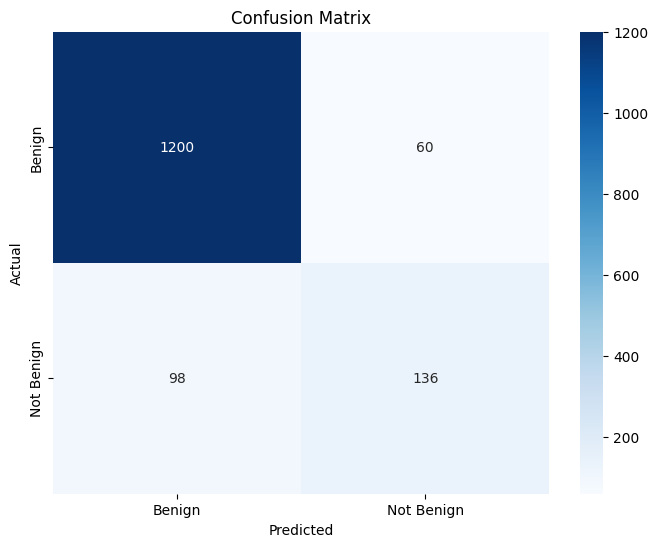

In [ ]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model_no_metadata(model_ham10000_pretrained_no_metadata, test_loader, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {100 * correct / total:.2f}%")


Epoch 1/50:   0%|          | 0/150 [00:10<?, ?it/s]


NameError: name 'F' is not defined

In [ ]:
model.eval()
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * val_correct / val_total:.2f}%")

Validation Accuracy: 91.14%


In [ ]:
############## add metadata #####################

In [ ]:
print(metadata.isnull().sum())
print(metadata.shape)

lesion_id        0
image_id         0
dx               0
dx_type          0
age             52
sex              0
localization     0
target           0
duplicates       0
image_path       0
full_path        0
dtype: int64
(7470, 11)


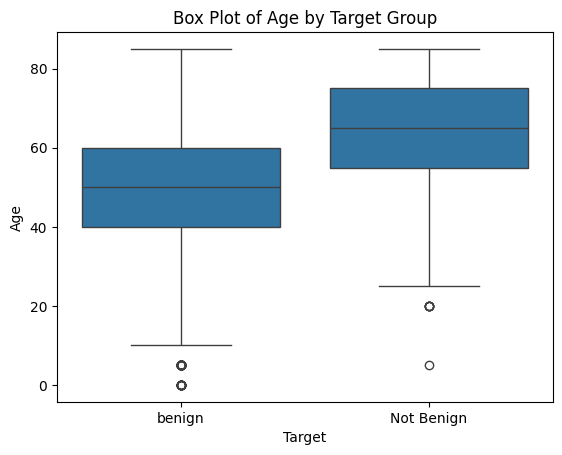

In [ ]:
sns.boxplot(x='target', y='age', data=metadata)
plt.title('Box Plot of Age by Target Group')
plt.xlabel('Target')
plt.ylabel('Age')
plt.show()

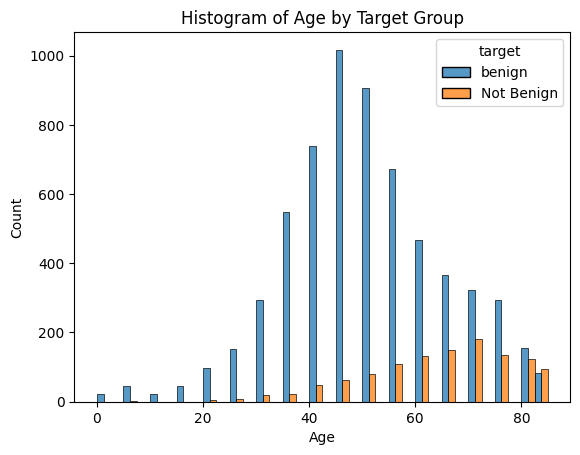

In [ ]:
#### histogram of age by group
sns.histplot(data=metadata, x='age', hue='target', kde=False, multiple='dodge')  # or 'dodge' if you prefer side-by-side
plt.title('Histogram of Age by Target Group')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [ ]:
missing_age = metadata[metadata['age'].isna()]
target_counts_missing_age = missing_age['target'].value_counts()
print(target_counts_missing_age)

target
benign        51
Not Benign     1
Name: count, dtype: int64


In [ ]:
mean_age_by_target = metadata.groupby('target')['age'].mean()
print(mean_age_by_target)
median_age_by_target = metadata.groupby('target')['age'].median()
print(median_age_by_target) ## impute median

target
Not Benign    63.891267
benign        49.372800
Name: age, dtype: float64
target
Not Benign    65.0
benign        50.0
Name: age, dtype: float64


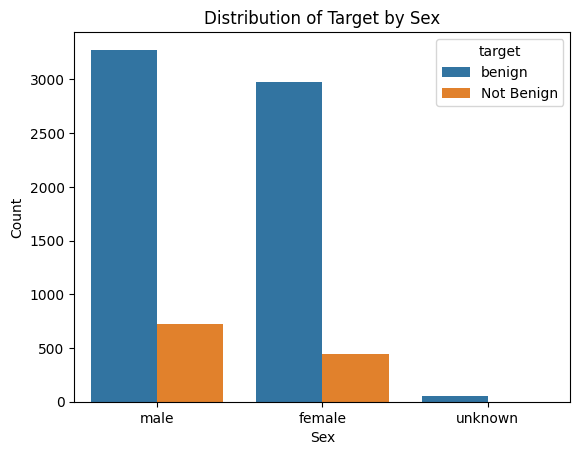

In [ ]:
sns.countplot(data=metadata, x='sex', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by Sex')
plt.show()

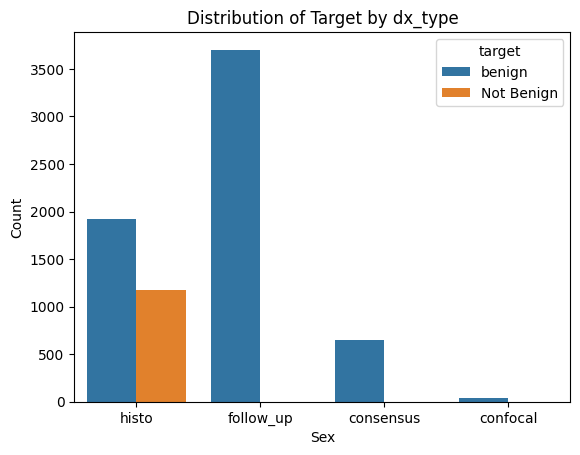

In [ ]:
sns.countplot(data=metadata, x='dx_type', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dx_type')
plt.show()

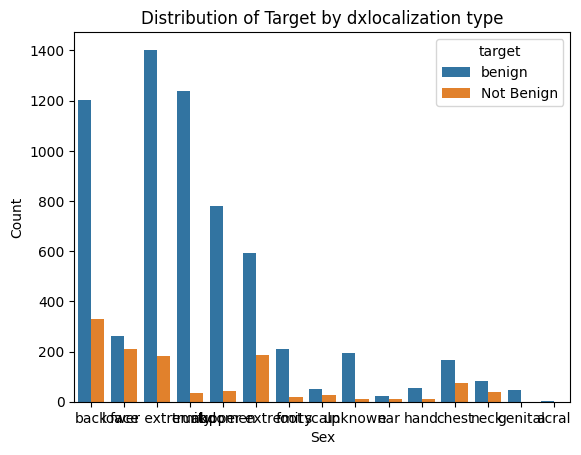

In [ ]:
sns.countplot(data=metadata, x='localization', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dxlocalization type')
plt.show()

In [ ]:
metadata['age'] = metadata.groupby('target')['age'].transform(lambda x: x.fillna(x.median()))
df_encoded = pd.get_dummies(metadata[['age', 'sex', 'localization']])

In [ ]:
df_encoded.head()

,age,sex_female,sex_male,sex_unknown,localization_abdomen,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,60.0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,70.0,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,65.0,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,55.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,40.0,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
class HAMDataset(Dataset):
    def __init__(self, df, meta_array, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label


In [ ]:
from sklearn.preprocessing import StandardScaler

#metadata['age'] = metadata['age'].fillna(metadata['age'].median())
metadata['sex'] = metadata['sex'].fillna('unknown')
metadata['localization'] = metadata['localization'].fillna('unknown')
meta_raw = metadata[['age', 'sex', 'localization']].copy()
meta_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
scaler = StandardScaler()
meta_encoded['age'] = scaler.fit_transform(meta_encoded[['age']])


In [ ]:
print(meta_encoded.head())

        age  sex_female  sex_male  sex_unknown  localization_abdomen  \
0  0.523200       False      True        False                 False   
1  1.149732        True     False        False                 False   
2  0.836466        True     False        False                 False   
3  0.209934       False      True        False                 False   
4 -0.729863        True     False        False                 False   

   localization_acral  localization_back  localization_chest  \
0               False               True               False   
1               False              False               False   
2               False              False               False   
3               False              False               False   
4               False               True               False   

   localization_ear  localization_face  localization_foot  \
0             False              False              False   
1             False               True              False   

In [ ]:
meta_encoded = meta_encoded.set_index(metadata.index)

# Select metadata rows for each split and convert
train_meta = torch.tensor(meta_encoded.loc[train_df.index].to_numpy().astype(np.float32))
val_meta   = torch.tensor(meta_encoded.loc[val_df.index].to_numpy().astype(np.float32))
test_meta  = torch.tensor(meta_encoded.loc[test_df.index].to_numpy().astype(np.float32))

In [ ]:
train_dataset = HAMDataset(train_df, meta_array=train_meta, transform=train_transforms)
val_dataset   = HAMDataset(val_df, meta_array=val_meta, transform=val_test_transforms)
test_dataset  = HAMDataset(test_df, meta_array=test_meta, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print(type(train_dataset[0]))

<class 'tuple'>


<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)


In [ ]:
print(train_meta.shape)


torch.Size([4780, 19])


In [ ]:
print(val_meta.shape)

torch.Size([1196, 19])


In [ ]:
print(test_meta.shape)

torch.Size([1494, 19])


In [ ]:
print(metadata['target'].value_counts())

target
benign        6301
Not Benign    1169
Name: count, dtype: int64


In [ ]:
def __getitem__(self, idx):
    row = self.metadata.iloc[idx]

    image = Image.open(row['full_path']).convert('RGB')
    if self.transform:
        image = self.transform(image)

    meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
    label = self.class_to_idx[row['target']]

    return image, meta_features, label


In [ ]:
class ResNetWithMetadata_old(nn.Module):
    def __init__(self, num_metadata_features, num_classes):
        super(ResNetWithMetadata, self).__init__()
        self.resnet = models.resnet101(pretrained=True)

        # Freeze all layers (optional)
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Replace ResNet's final layer with identity
        self.resnet.fc = nn.Identity()

        # MLP for metadata
        self.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Final classifier that combines image and metadata features
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, metadata):
        image_features = self.resnet(image)           # [batch, 2048]
        metadata_features = self.meta_fc(metadata)    # [batch, 32]
        combined = torch.cat((image_features, metadata_features), dim=1)
        output = self.classifier(combined)
        return output

In [ ]:
class ResNetWithMetadata(nn.Module):
    def __init__(self, num_metadata_features, num_classes):
        super(ResNetWithMetadata, self).__init__()

        # Load pretrained ResNet101
        self.resnet = models.resnet101(pretrained=True)

        # Unfreeze only the last block (layer4) for fine-tuning
        for name, param in self.resnet.named_parameters():
            param.requires_grad = True if "layer4" in name else False

        # Replace ResNet's classification head with identity
        self.resnet.fc = nn.Identity()

        # Metadata MLP with BatchNorm
        self.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Optional: Gating mechanism to balance image vs metadata features
        self.gate = nn.Sequential(
            nn.Linear(2048 + 32, 1),
            nn.Sigmoid()
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, metadata):
        # Extract features
        image_features = self.resnet(image)              # [batch, 2048]
        metadata_features = self.meta_fc(metadata)       # [batch, 32]

        # Concatenate both
        combined = torch.cat((image_features, metadata_features), dim=1)  # [batch, 2080]

        # Apply gating (optional attention-like weighting)
        gate_value = self.gate(combined)                 # [batch, 1]
        combined = gate_value * combined                 # scaled features

        # Final classification
        output = self.classifier(combined)
        return output

In [ ]:
num_metadata_features = train_meta.shape[1]
num_classes = len(train_dataset.classes)
model = ResNetWithMetadata(num_metadata_features=num_metadata_features,num_classes=num_classes).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 226MB/s]


In [ ]:
!pip install focal-loss

In [ ]:
#import torch.optim as optim

#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for classification tasks.
        Args:
            alpha (tensor): class weights (shape: [num_classes])
            gamma (float): focusing parameter
            reduction (str): 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [ ]:
class_weights = torch.tensor([1.0, 5.39], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
EPOCHS = 50
save_path = 'best_model.pth'
best_f1 = 0

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, metadata, labels in dataloader:
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(images, metadata)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs


In [ ]:
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

### best
#🚀 Epoch 36/50
#Training Epoch 36/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
#  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
#Training Epoch 36/50: 100%|██████████| 150/150 [01:04<00:00,  2.34it/s, acc=90.8, loss=0.322]
#✅ Training Loss: 0.1555 | Accuracy: 90.82%
#✅ Eval Accuracy: 91.89%
#📊 Validation F1 Score: 0.9533
#📈 Validation AUC: 0.9490
#🧾 Confusion Matrix:
#[[110  77]
# [ 20 989]]
#💾 Saved new best model with F1: 0.9533


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 150/150 [01:05<00:00,  2.30it/s, acc=84.1, loss=0.162]


✅ Training Loss: 0.3834 | Accuracy: 84.14%
✅ Eval Accuracy: 84.36%
📊 Validation F1 Score: 0.9152
📈 Validation AUC: 0.9139
🧾 Confusion Matrix:
[[   0  187]
 [   0 1009]]
💾 Saved new best model with F1: 0.9152

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 150/150 [01:04<00:00,  2.31it/s, acc=84.4, loss=0.686]


✅ Training Loss: 0.2774 | Accuracy: 84.35%
✅ Eval Accuracy: 84.36%
📊 Validation F1 Score: 0.9152
📈 Validation AUC: 0.9383
🧾 Confusion Matrix:
[[   0  187]
 [   0 1009]]

🚀 Epoch 3/50


...

✅ Training Loss: 0.1277 | Accuracy: 92.76%
✅ Eval Accuracy: 89.88%
📊 Validation F1 Score: 0.9433
📈 Validation AUC: 0.9483
🧾 Confusion Matrix:
[[  69  118]
 [   3 1006]]

🚀 Epoch 49/50


Training Epoch 49/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 49/50: 100%|██████████| 150/150 [01:04<00:00,  2.33it/s, acc=92.1, loss=0.0452]


✅ Training Loss: 0.1221 | Accuracy: 92.11%
✅ Eval Accuracy: 88.88%
📊 Validation F1 Score: 0.9381
📈 Validation AUC: 0.9378
🧾 Confusion Matrix:
[[  56  131]
 [   2 1007]]

🚀 Epoch 50/50


Training Epoch 50/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 50/50: 100%|██████████| 150/150 [01:03<00:00,  2.35it/s, acc=93.1, loss=0.261]


✅ Training Loss: 0.1188 | Accuracy: 93.05%
✅ Eval Accuracy: 89.80%
📊 Validation F1 Score: 0.9426
📈 Validation AUC: 0.9354
🧾 Confusion Matrix:
[[  73  114]
 [   8 1001]]


In [ ]:
## change class weights learning rate 5e-4  epoch 150 good
## change class weights learning rate 2e-4  epoch 250
class_weights = torch.tensor([1.0, 5.39], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)
EPOCHS = 250
save_path = 'best_model.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=0.0002)

In [ ]:
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")


🚀 Epoch 1/250


Training Epoch 1/250:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-17-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 1/250:   4%|▍         | 6/150 [00:04<01:20,  1.80it/s, acc=88.5, loss=0.185]

In [ ]:
##🚀 Epoch 86/150
#Training Epoch 86/150:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
#  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
#Training Epoch 86/150: 100%|██████████| 150/150 [01:04<00:00,  2.33it/s, acc=94.8, loss=0.45]
#✅ Training Loss: 0.0846 | Accuracy: 94.83%
#✅ Eval Accuracy: 92.14%
#📊 Validation F1 Score: 0.9548
#📈 Validation AUC: 0.9439
#🧾 Confusion Matrix:
#[[109  78]
# [ 16 993]]
#💾 Saved new best model with F1: 0.9548




Training Epoch 136/150:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
Training Epoch 136/150: 100%|██████████| 150/150 [01:04<00:00,  2.34it/s, acc=95.8, loss=0.0018]
✅ Training Loss: 0.0710 | Accuracy: 95.82%
✅ Eval Accuracy: 91.30%
📊 Validation F1 Score: 0.9495
📈 Validation AUC: 0.9382
🧾 Confusion Matrix:
[[114  73]
 [ 31 978]]


In [ ]:
############## add resnet + xgboost #####################

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

In [ ]:
xgb = XGBClassifier(n_estimators=100)

In [ ]:
metadata['age'] = metadata.groupby('target')['age'].transform(lambda x: x.fillna(x.median()))
df_encoded = pd.get_dummies(metadata[['age', 'sex', 'localization']])

In [ ]:
print(metadata.shape)

(7470, 11)


In [ ]:
print(metadata.head())

     lesion_id      image_id   dx    dx_type   age     sex     localization  \
0  HAM_0000000  ISIC_0025346   nv      histo  60.0    male             back   
1  HAM_0000001  ISIC_0027859  bkl      histo  70.0  female             face   
2  HAM_0000002  ISIC_0032622  mel      histo  65.0  female  lower extremity   
3  HAM_0000003  ISIC_0027886   nv  follow_up  55.0    male            trunk   
4  HAM_0000004  ISIC_0024645   nv  follow_up  40.0  female             back   

       target    duplicates        image_path                    full_path  
0      benign    duplicated  ISIC_0025346.jpg  all_images/ISIC_0025346.jpg  
1      benign  unduplicated  ISIC_0027859.jpg  all_images/ISIC_0027859.jpg  
2  Not Benign    duplicated  ISIC_0032622.jpg  all_images/ISIC_0032622.jpg  
3      benign  unduplicated  ISIC_0027886.jpg  all_images/ISIC_0027886.jpg  
4      benign  unduplicated  ISIC_0024645.jpg  all_images/ISIC_0024645.jpg  


In [ ]:
boostdata= metadata

In [ ]:
boostdata['sex'] = LabelEncoder().fit_transform(boostdata['sex'])  # male=1, female=0
boostdata['localization'] = LabelEncoder().fit_transform(boostdata['localization'])
boostdata['dx_type'] = LabelEncoder().fit_transform(boostdata['dx_type'])

In [ ]:
print(boostdata.head())

     lesion_id      image_id   dx  dx_type   age  sex  localization  \
0  HAM_0000000  ISIC_0025346   nv        3  60.0    1             2   
1  HAM_0000001  ISIC_0027859  bkl        3  70.0    0             5   
2  HAM_0000002  ISIC_0032622  mel        3  65.0    0             9   
3  HAM_0000003  ISIC_0027886   nv        2  55.0    1            12   
4  HAM_0000004  ISIC_0024645   nv        2  40.0    0             2   

       target    duplicates        image_path                    full_path  
0      benign    duplicated  ISIC_0025346.jpg  all_images/ISIC_0025346.jpg  
1      benign  unduplicated  ISIC_0027859.jpg  all_images/ISIC_0027859.jpg  
2  Not Benign    duplicated  ISIC_0032622.jpg  all_images/ISIC_0032622.jpg  
3      benign  unduplicated  ISIC_0027886.jpg  all_images/ISIC_0027886.jpg  
4      benign  unduplicated  ISIC_0024645.jpg  all_images/ISIC_0024645.jpg  


In [ ]:
tabular_features = ['age', 'sex', 'localization', 'dx_type']
X_tabular = boostdata[tabular_features]

In [ ]:
boostdata['target_bin'] = boostdata['target'].map({'benign': 0, 'Not Benign': 1})
y_target = boostdata['target_bin']

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, max_depth=3)
xgb_model.fit(X_tabular, y_target)
xgb_preds = xgb_model.predict(X_tabular)

In [ ]:
boostdata['xgb_risk_score'] = xgb_preds

In [ ]:
print(boostdata.head(), boostdata.shape)

     lesion_id      image_id   dx  dx_type   age  sex  localization  \
0  HAM_0000000  ISIC_0025346   nv        3  60.0    1             2   
1  HAM_0000001  ISIC_0027859  bkl        3  70.0    0             5   
2  HAM_0000002  ISIC_0032622  mel        3  65.0    0             9   
3  HAM_0000003  ISIC_0027886   nv        2  55.0    1            12   
4  HAM_0000004  ISIC_0024645   nv        2  40.0    0             2   

       target    duplicates        image_path                    full_path  \
0      benign    duplicated  ISIC_0025346.jpg  all_images/ISIC_0025346.jpg   
1      benign  unduplicated  ISIC_0027859.jpg  all_images/ISIC_0027859.jpg   
2  Not Benign    duplicated  ISIC_0032622.jpg  all_images/ISIC_0032622.jpg   
3      benign  unduplicated  ISIC_0027886.jpg  all_images/ISIC_0027886.jpg   
4      benign  unduplicated  ISIC_0024645.jpg  all_images/ISIC_0024645.jpg   

   target_bin  xgb_risk_score  
0           0        0.434077  
1           0        0.623191  
2       

In [ ]:
boostdata_analyis = boostdata[['xgb_risk_score', 'target', 'full_path']]
print(boostdata_analyis.shape)

(7470, 3)


In [ ]:
class HAMDataset(Dataset):
    def __init__(self, df, meta_array, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label

In [ ]:
boostdata_encoded = boostdata_analyis.set_index(metadata.index)

In [ ]:
boostdata_encoded.head()

,xgb_risk_score,target,full_path
0,0.434077,benign,all_images/ISIC_0025346.jpg
1,0.623191,benign,all_images/ISIC_0027859.jpg
2,0.454887,Not Benign,all_images/ISIC_0032622.jpg
3,0.003524,benign,all_images/ISIC_0027886.jpg
4,0.001253,benign,all_images/ISIC_0024645.jpg


In [ ]:
train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['target'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['target'], random_state=42)

In [ ]:
boostdata_train_meta = torch.tensor(boostdata_encoded.loc[train_df.index, ['xgb_risk_score']].to_numpy().astype(np.float32))
boostdata_val_meta   = torch.tensor(boostdata_encoded.loc[val_df.index, ['xgb_risk_score']].to_numpy().astype(np.float32))
boostdata_test_meta  = torch.tensor(boostdata_encoded.loc[test_df.index, ['xgb_risk_score']].to_numpy().astype(np.float32))

In [ ]:
IMG_SIZE = (224, 224)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transforms for validation & test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

In [ ]:
def __getitem__(self, idx):
    row = self.boostdata_encoded.iloc[idx]

    image = Image.open(row['full_path']).convert('RGB')
    if self.transform:
        image = self.transform(image)

    meta_features = torch.tensor(self.boostdata_encoded[idx], dtype=torch.float32)
    label = self.class_to_idx[row['target']]

    return image, meta_features, label

In [ ]:
class ResNetWithXGBoostFusion(nn.Module):
    def __init__(self, xgb_feature_dim=1, combined_hidden_dim=128):
        super(ResNetWithXGBoostFusion, self).__init__()

        # CNN base: ResNet101 (pretrained)
        self.cnn = models.resnet101(pretrained=True)
        self.cnn.fc = nn.Identity()  # remove last FC layer

        cnn_output_dim = 2048  # ResNet101 output feature vector size

        # Final classifier takes CNN + xgb_score
        self.classifier = nn.Sequential(
            nn.Linear(cnn_output_dim + xgb_feature_dim, combined_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(combined_hidden_dim, 1),
            nn.Sigmoid()  # for binary classification
        )

    def forward(self, images, xgb_scores):
        cnn_features = self.cnn(images)                 # shape: [B, 2048]
        combined = torch.cat((cnn_features, xgb_scores), dim=1)  # [B, 2049]
        return self.classifier(combined)

In [ ]:
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['full_path']
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # xgb risk score → tensor of shape [1]
        xgb_score = torch.tensor([row['xgb_risk_score']], dtype=torch.float32)

        # target: 0 = benign, 1 = not benign
        label = 1 if row['target'] == 'Not Benign' else 0
        label = torch.tensor([label], dtype=torch.float32)

        return image, xgb_score, label

In [ ]:
boostdata_train_dataset = HAMDataset(train_df, transform=train_transforms)
boostdata_val_dataset   = HAMDataset(val_df, transform=val_test_transforms)
boostdata_test_dataset  = HAMDataset(test_df, transform=val_test_transforms)

boostdata_train_loader = DataLoader(boostdata_train_dataset, batch_size=32, shuffle=True)
boostdata_val_loader   = DataLoader(boostdata_val_dataset, batch_size=32, shuffle=False)
boostdata_test_loader  = DataLoader(boostdata_test_dataset, batch_size=32, shuffle=False)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # tensor([1.0, 5.39])
        self.gamma = gamma

    def forward(self, inputs, targets):
        # inputs: raw logits of shape [B, 1]
        # targets: binary ground truth shape [B, 1]
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)

        if self.alpha is not None:
            at = self.alpha[targets.long().view(-1)].view(-1, 1)  # shape [B, 1]
            BCE_loss = at * BCE_loss

        loss = (1 - pt) ** self.gamma * BCE_loss
        return loss.mean()
### new focal loss

In [ ]:
EPOCHS = 50
learning_rate = 1e-4
save_path = 'best_model.pth'
best_f1 = 0

class_weights = torch.tensor([1.0, 5.39], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

model = ResNetWithXGBoostFusion()
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, xgb_scores, labels in dataloader:
            images = images.to(device)
            xgb_scores = xgb_scores.to(device)
            labels = labels.to(device)

            outputs = model(images, xgb_scores)
            probs = torch.sigmoid(outputs).squeeze()  # shape [B]
            predicted = (probs > 0.5).long()

            total += labels.size(0)
            correct += (predicted == labels.long().squeeze()).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

In [ ]:
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(boostdata_train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, xgb_scores, labels in loop:
        images = images.to(device)
        xgb_scores = xgb_scores.to(device)
        labels = labels.float().to(device).view(-1, 1)  # Ensure shape [B, 1]

        optimizer.zero_grad()
        outputs = model(images, xgb_scores)  # shape: [B, 1]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()
        correct += (preds == labels.squeeze().long()).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # Training metrics
    train_loss = running_loss / len(boostdata_train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # Validation
    val_preds, val_labels, val_probs = evaluate_model(model, boostdata_val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # Save best model
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")



🚀 Epoch 1/50


Training Epoch 1/50: 100%|██████████| 150/150 [01:11<00:00,  2.11it/s, acc=15.6, loss=0.21]


✅ Training Loss: 0.2473 | Accuracy: 15.65%
✅ Eval Accuracy: 15.64%
📊 Validation F1 Score: 0.2704
📈 Validation AUC: 0.9323
🧾 Confusion Matrix:
[[   0 1009]
 [   0  187]]
💾 Saved new best model with F1: 0.2704

🚀 Epoch 2/50


Training Epoch 2/50: 100%|██████████| 150/150 [01:16<00:00,  1.97it/s, acc=15.9, loss=0.276]


✅ Training Loss: 0.2456 | Accuracy: 15.88%
✅ Eval Accuracy: 15.72%
📊 Validation F1 Score: 0.2706
📈 Validation AUC: 0.9338
🧾 Confusion Matrix:
[[   1 1008]
 [   0  187]]
💾 Saved new best model with F1: 0.2706

🚀 Epoch 3/50


...

✅ Training Loss: 0.2184 | Accuracy: 62.66%
✅ Eval Accuracy: 66.97%
📊 Validation F1 Score: 0.4837
📈 Validation AUC: 0.9311
🧾 Confusion Matrix:
[[616 393]
 [  2 185]]

🚀 Epoch 49/50


Training Epoch 49/50: 100%|██████████| 150/150 [01:11<00:00,  2.10it/s, acc=65.5, loss=0.169]


✅ Training Loss: 0.2134 | Accuracy: 65.50%
✅ Eval Accuracy: 72.32%
📊 Validation F1 Score: 0.5210
📈 Validation AUC: 0.9320
🧾 Confusion Matrix:
[[685 324]
 [  7 180]]

🚀 Epoch 50/50


Training Epoch 50/50: 100%|██████████| 150/150 [01:11<00:00,  2.11it/s, acc=64.8, loss=0.255]


✅ Training Loss: 0.2175 | Accuracy: 64.77%
✅ Eval Accuracy: 67.81%
📊 Validation F1 Score: 0.4914
📈 Validation AUC: 0.9448
🧾 Confusion Matrix:
[[625 384]
 [  1 186]]


In [ ]:
EPOCHS = 200
learning_rate = 2e-4
save_path = 'best_model.pth'
best_f1 = 0

class_weights = torch.tensor([1.0, 5.39], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

model = ResNetWithXGBoostFusion()
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(boostdata_train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, xgb_scores, labels in loop:
        images = images.to(device)
        xgb_scores = xgb_scores.to(device)
        labels = labels.float().to(device).view(-1, 1)  # Ensure shape [B, 1]

        optimizer.zero_grad()
        outputs = model(images, xgb_scores)  # shape: [B, 1]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > 0.5).long()
        correct += (preds == labels.squeeze().long()).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # Training metrics
    train_loss = running_loss / len(boostdata_train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # Validation
    val_preds, val_labels, val_probs = evaluate_model(model, boostdata_val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # Save best model
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")


🚀 Epoch 1/200


Training Epoch 1/200: 100%|██████████| 150/150 [01:10<00:00,  2.11it/s, acc=16.1, loss=0.331]


✅ Training Loss: 0.2655 | Accuracy: 16.07%
✅ Eval Accuracy: 17.98%
📊 Validation F1 Score: 0.2760
📈 Validation AUC: 0.8939
🧾 Confusion Matrix:
[[ 28 981]
 [  0 187]]
💾 Saved new best model with F1: 0.2760

🚀 Epoch 2/200


Training Epoch 2/200: 100%|██████████| 150/150 [01:16<00:00,  1.97it/s, acc=16.3, loss=0.179]


✅ Training Loss: 0.2571 | Accuracy: 16.30%
✅ Eval Accuracy: 19.31%
📊 Validation F1 Score: 0.2650
📈 Validation AUC: 0.8126
🧾 Confusion Matrix:
[[ 57 952]
 [ 13 174]]

🚀 Epoch 3/200


...

✅ Training Loss: 0.2062 | Accuracy: 46.97%
✅ Eval Accuracy: 54.01%
📊 Validation F1 Score: 0.4048
📈 Validation AUC: 0.9481
🧾 Confusion Matrix:
[[459 550]
 [  0 187]]

🚀 Epoch 199/200


Training Epoch 199/200: 100%|██████████| 150/150 [01:11<00:00,  2.11it/s, acc=52.9, loss=0.407]


✅ Training Loss: 0.2052 | Accuracy: 52.95%
✅ Eval Accuracy: 64.30%
📊 Validation F1 Score: 0.4629
📈 Validation AUC: 0.9427
🧾 Confusion Matrix:
[[585 424]
 [  3 184]]

🚀 Epoch 200/200


Training Epoch 200/200: 100%|██████████| 150/150 [01:10<00:00,  2.12it/s, acc=50.9, loss=0.259]


✅ Training Loss: 0.2049 | Accuracy: 50.92%
✅ Eval Accuracy: 49.16%
📊 Validation F1 Score: 0.3783
📈 Validation AUC: 0.9426
🧾 Confusion Matrix:
[[403 606]
 [  2 185]]


In [ ]:
num_epochs = 10
learning_rate = 1e-4


model = ResNetWithXGBoostFusion()
model.to(device)


criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, xgb_scores, labels in boostdata_train_loader:
        images = images.to(device)
        xgb_scores = xgb_scores.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, xgb_scores)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:02<00:00, 66.2MB/s]


Epoch [1/10], Loss: 45.4741
Epoch [2/10], Loss: 42.5254
Epoch [3/10], Loss: 41.1736
Epoch [4/10], Loss: 39.8525
Epoch [5/10], Loss: 37.3697
Epoch [6/10], Loss: 38.0505
Epoch [7/10], Loss: 37.1839
Epoch [8/10], Loss: 36.1175
Epoch [9/10], Loss: 35.9896
Epoch [10/10], Loss: 36.5088


In [ ]:
########### not run below

In [ ]:
from tqdm import tqdm

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # tqdm live update
        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f"📊 Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

    # Optional: Validation after each epoch
    # val_preds, val_labels = evaluate_model(model, val_loader, device)


In [ ]:
for images, metadata, labels in train_loader:
    images = images.to(device)
    metadata = metadata.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images, metadata)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

<ipython-input-49-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)


In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, metadata, labels in dataloader:
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(images, metadata)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Evaluation Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels


In [ ]:
# After training is done:
val_preds, val_labels = evaluate_model(model, val_loader, device)

# Or for test set
test_preds, test_labels = evaluate_model(model, test_loader, device)


<ipython-input-32-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)


✅ Evaluation Accuracy: 80.54%
✅ Evaluation Accuracy: 80.73%


              precision    recall  f1-score   support

  Not Benign       0.67      0.01      0.01       313
      benign       0.81      1.00      0.89      1290

    accuracy                           0.81      1603
   macro avg       0.74      0.50      0.45      1603
weighted avg       0.78      0.81      0.72      1603



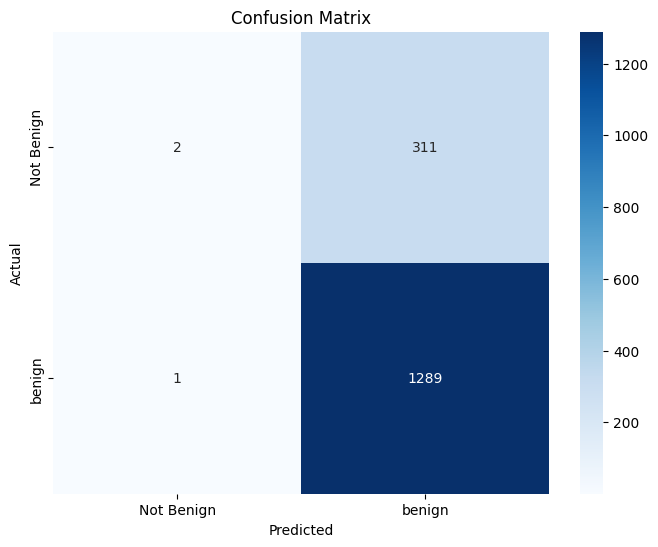

In [ ]:
# Print classification report
print(classification_report(val_labels, val_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()